<a href="https://colab.research.google.com/github/punyakj3-gif/pooja07/blob/main/miniprj1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HOUSE PRICE DATASET
    Area  Bedrooms  Bathrooms  Age  Price
0    800         1          1   20     20
1    900         2          1   18     23
2   1000         2          2   15     27
3   1100         2          2   14     30
4   1200         2          2   12     34
5   1300         3          2   10     39
6   1400         3          2   10     43
7   1500         3          2    9     47
8   1600         3          2    8     51
9   1700         3          3    8     55
10  1800         3          3    7     60
11  1900         3          3    6     64
12  2000         4          3    6     70
13  2100         4          3    5     75
14  2200         4          3    5     80
15  2300         4          3    4     86
16  2400         4          3    4     92
17  2500         4          4    3    100
18  2700         5          4    2    112
19  3000         5          4    1    125

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data c

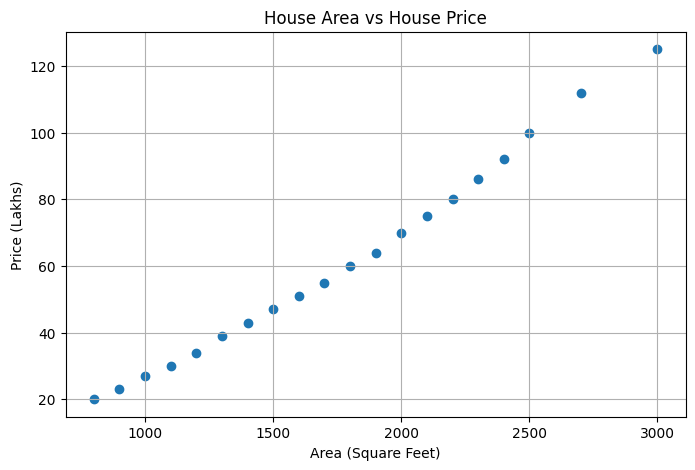

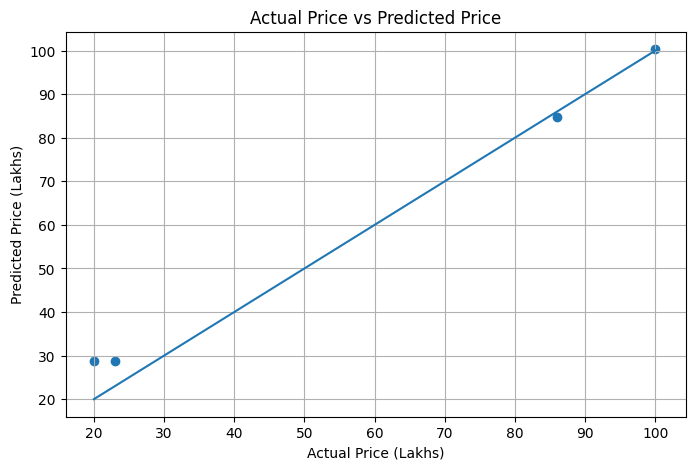

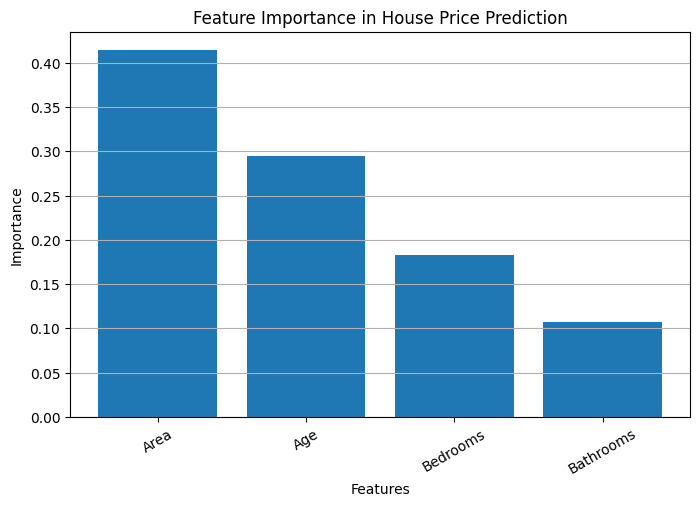


FINAL RESULT
House price prediction completed successfully.
Predicted price for the new house = 88.39 Lakhs
Program Completed Successfully!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
data = {
    'Area': [
        800, 900, 1000, 1100, 1200,
        1300, 1400, 1500, 1600, 1700,
        1800, 1900, 2000, 2100, 2200,
        2300, 2400, 2500, 2700, 3000
    ],
    'Bedrooms': [
        1, 2, 2, 2, 2,
        3, 3, 3, 3, 3,
        3, 3, 4, 4, 4,
        4, 4, 4, 5, 5
    ],
     'Bathrooms': [
        1, 1, 2, 2, 2,
        2, 2, 2, 2, 3,
        3, 3, 3, 3, 3,
        3, 3, 4, 4, 4
    ],
    'Age': [
        20, 18, 15, 14, 12,
        10, 10, 9, 8, 8,
        7, 6, 6, 5, 5,
        4, 4, 3, 2, 1
    ],
    'Price': [
        20, 23, 27, 30, 34,
        39, 43, 47, 51, 55,
        60, 64, 70, 75, 80,
        86, 92, 100, 112, 125
    ]
}
df = pd.DataFrame(data)
print("=" * 60)
print("HOUSE PRICE DATASET")
print("=" * 60)
print(df)
print("\nDataset Information:")
print(df.info())
print("\nStatistical Description:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())
X = df[['Area', 'Bedrooms', 'Bathrooms', 'Age']]
y = df['Price']
print("\nInput Features:")
print(X.head())
print("\nTarget Values:")
print(y.head())
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("\nTraining Data Size:", len(X_train))
print("Testing Data Size:", len(X_test))
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=None
)
print("\nTraining Random Forest Model...")
model.fit(X_train, y_train)
print("Model Training Completed!")
y_pred = model.predict(X_test)
print("\nActual vs Predicted Prices")
print("-" * 45)
for actual, predicted in zip(y_test, y_pred):
    print(
        "Actual Price:",
        actual,
        "Lakhs | Predicted Price:",
        round(predicted, 2),
        "Lakhs"
    )
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("\n" + "=" * 60)
print("MODEL EVALUATION")
print("=" * 60)
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R2 Score:", round(r2, 2))
print("\n" + "=" * 60)
print("NEW HOUSE PRICE PREDICTION")
print("=" * 60)
new_house = pd.DataFrame({
    'Area': [2300],
    'Bedrooms': [4],
    'Bathrooms': [3],
    'Age': [3]
})
print("\nNew House Details:")
print(new_house)
new_price = model.predict(new_house)
print(
    "\nPredicted House Price:",
    round(new_price[0], 2),
    "Lakhs"
)
importance = model.feature_importances_
feature_names = X.columns
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)
print(feature_importance)
plt.figure(figsize=(8, 5))
plt.scatter(
    df['Area'],
    df['Price'],
    marker='o'
)
plt.xlabel("Area (Square Feet)")
plt.ylabel("Price (Lakhs)")
plt.title("House Area vs House Price")
plt.grid(True)
plt.show()
plt.figure(figsize=(8, 5))
plt.scatter(
    y_test,
    y_pred,
    marker='o'
)
plt.xlabel("Actual Price (Lakhs)")
plt.ylabel("Predicted Price (Lakhs)")
plt.title("Actual Price vs Predicted Price")
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())
plt.plot(
    [minimum, maximum],
    [minimum, maximum]
)
plt.grid(True)
plt.show()
plt.figure(figsize=(8, 5))
plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance in House Price Prediction")
plt.xticks(rotation=30)
plt.grid(axis='y')
plt.show()
print("\n" + "=" * 60)
print("FINAL RESULT")
print("=" * 60)
print("House price prediction completed successfully.")
print(
    "Predicted price for the new house =",
    round(new_price[0], 2),
    "Lakhs"
)
print("Program Completed Successfully!")